In [1]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np

# node2vec
from node2vec import Node2Vec

# clustering
from sklearn.cluster import KMeans, DBSCAN

# deep stuff
import torch
from torch_geometric.utils import from_networkx

/home/jann/GAT/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.community_results import community_metrics, plot_communities
from src.clustering import label_propagation, louvain, leiden
from src.DGIModel import DGIModel
from src.tune import tune

In [3]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [4]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [5]:
graphs = dict()

In [6]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [7]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [8]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'] .number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'] .is_directed()

(34, 78, False)

# Select Dataset

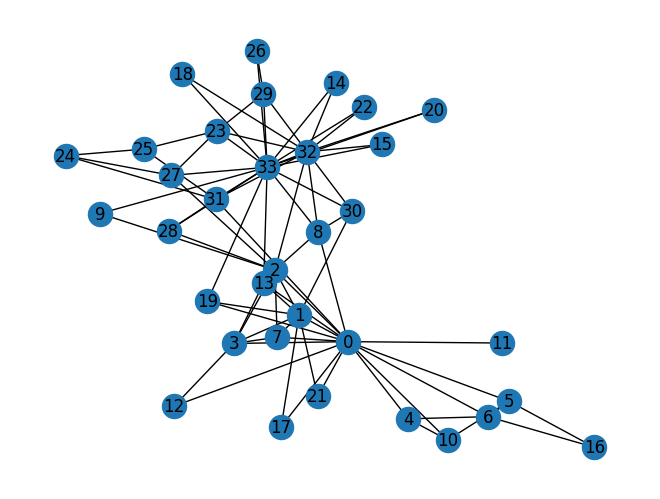

In [9]:
sel_graph = 'karate'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

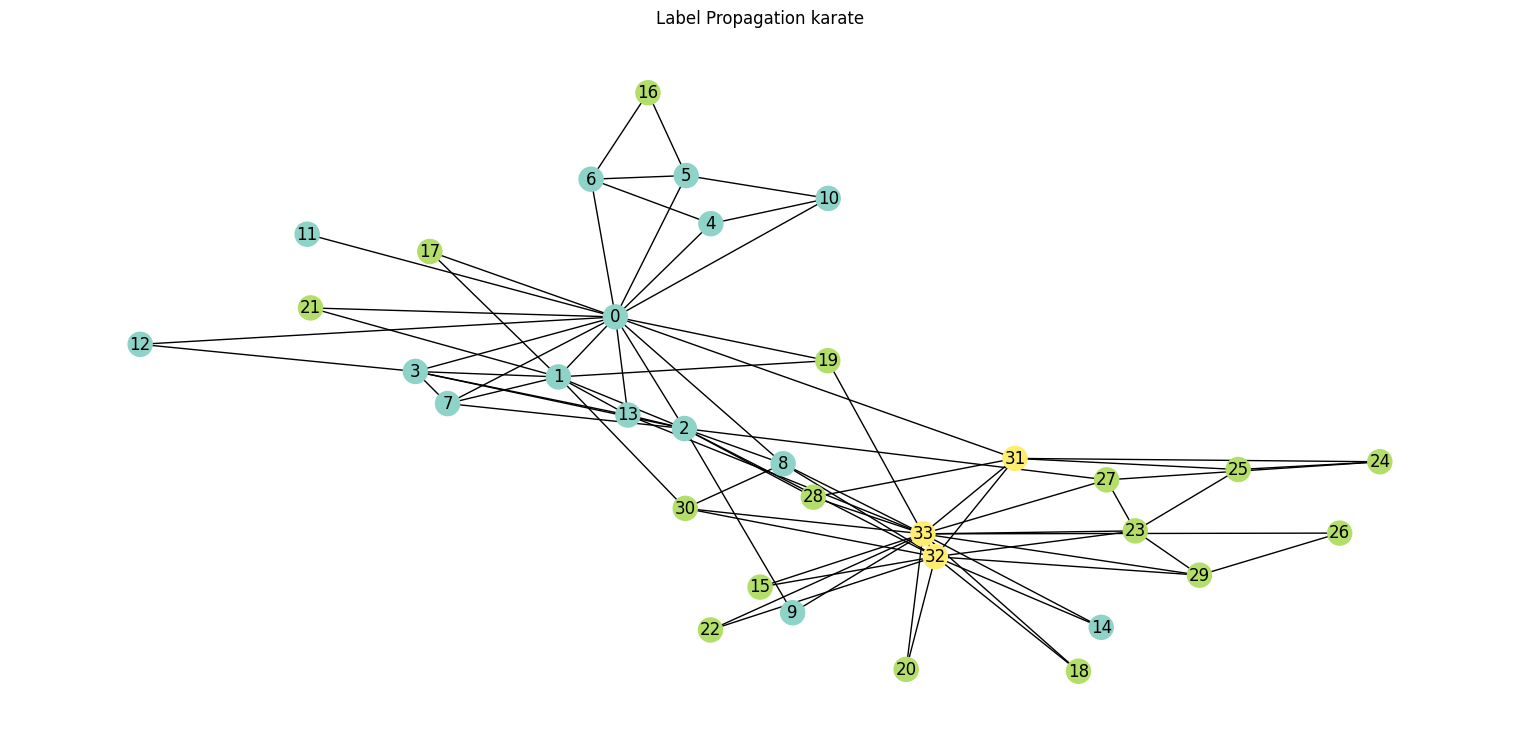

{'Number of Communities': 3,
 'Average Community Size': 11.333333333333334,
 'Modularity': 0.30948632896684847,
 'Coverage': 0.7692307692307693,
 'Performance': 0.6684491978609626}

In [10]:
lp_labels = label_propagation(g)

plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}")

# Calculate metrics for Louvain
lp_metrics = community_metrics(g, lp_labels)
lp_metrics

## Louvain

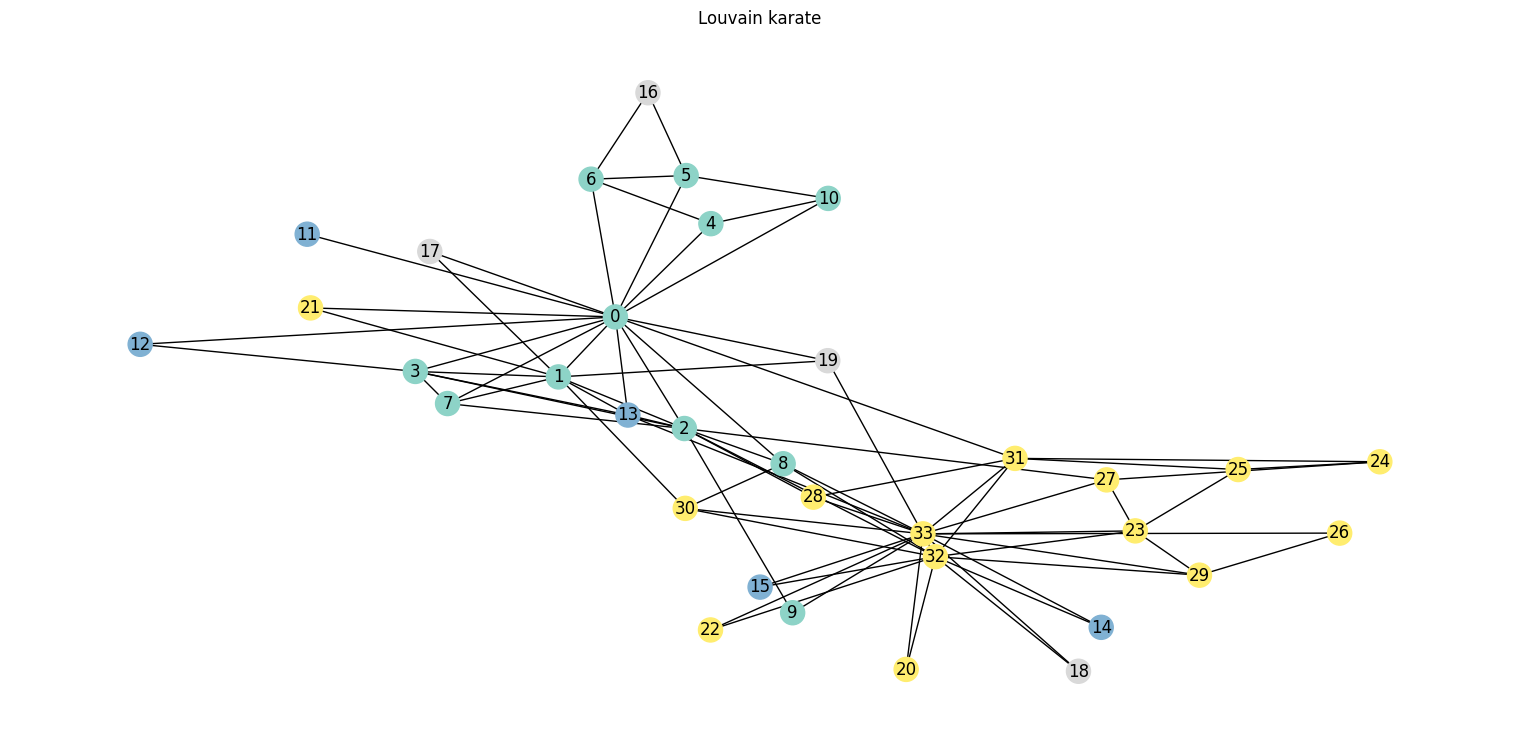

{'Number of Communities': 4,
 'Average Community Size': 8.5,
 'Modularity': 0.4438541256723075,
 'Coverage': 0.7564102564102564,
 'Performance': 0.7825311942959001}

In [11]:
lv_labels = louvain(g)

plot_communities(g, lv_labels, title=f"Louvain {sel_graph}")

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_metrics

## Leiden

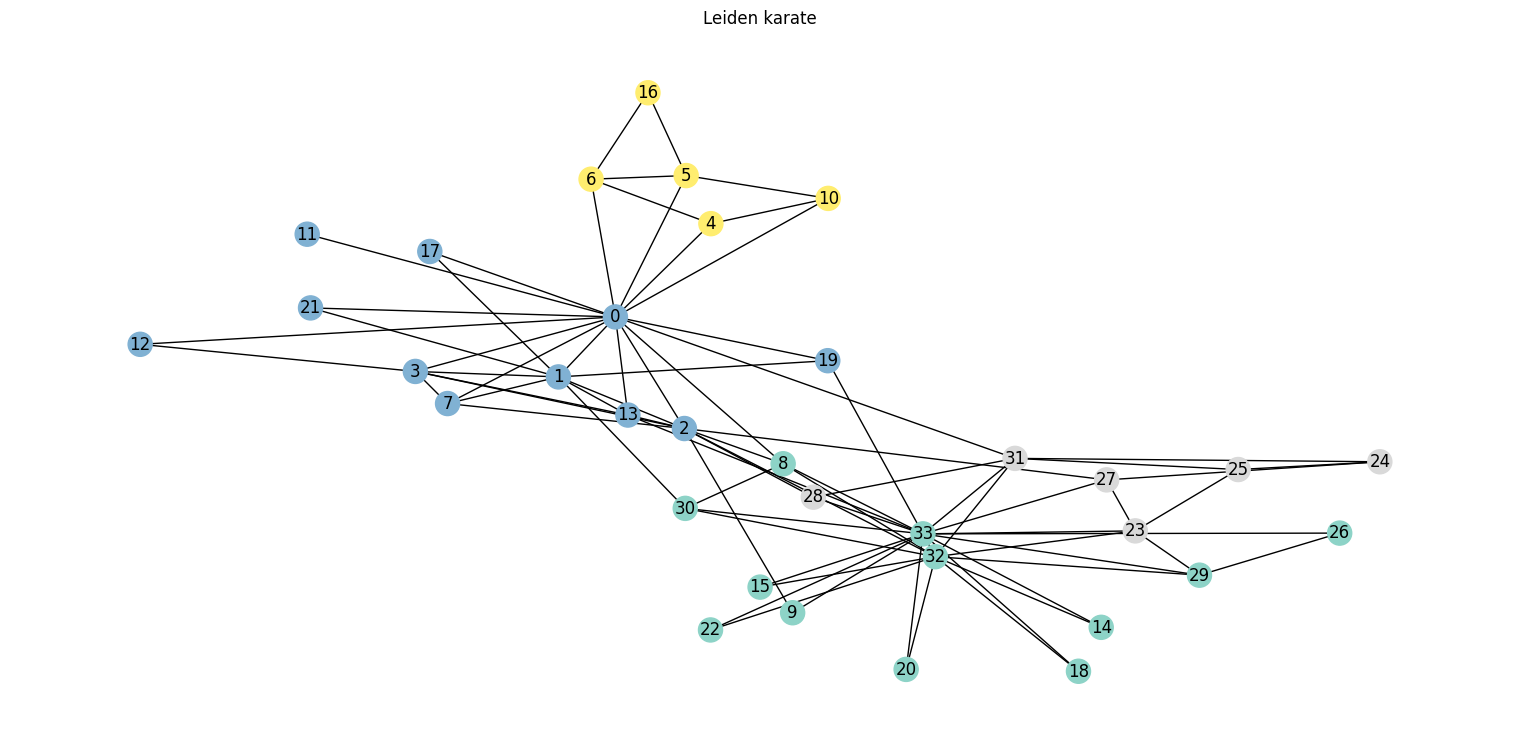

{'Number of Communities': 4,
 'Average Community Size': 8.5,
 'Modularity': 0.44490358126721763,
 'Coverage': 0.7307692307692307,
 'Performance': 0.803921568627451}

In [12]:
ld_labels = leiden(g)

plot_communities(g, ld_labels, title=f"Leiden {sel_graph}")

# Calculate metrics for Louvain
ld_metrics = community_metrics(g, ld_labels)
ld_metrics

# node2vec

In [13]:
node2vec = Node2Vec(g, dimensions=32, walk_length=20, num_walks=100, workers=4) 

# Embed nodes
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)  # Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)


Generating walks (CPU: 2): 100%|██████████| 25/25 [00:00<00:00, 830.08it/s]


## Clustering using node2vec only

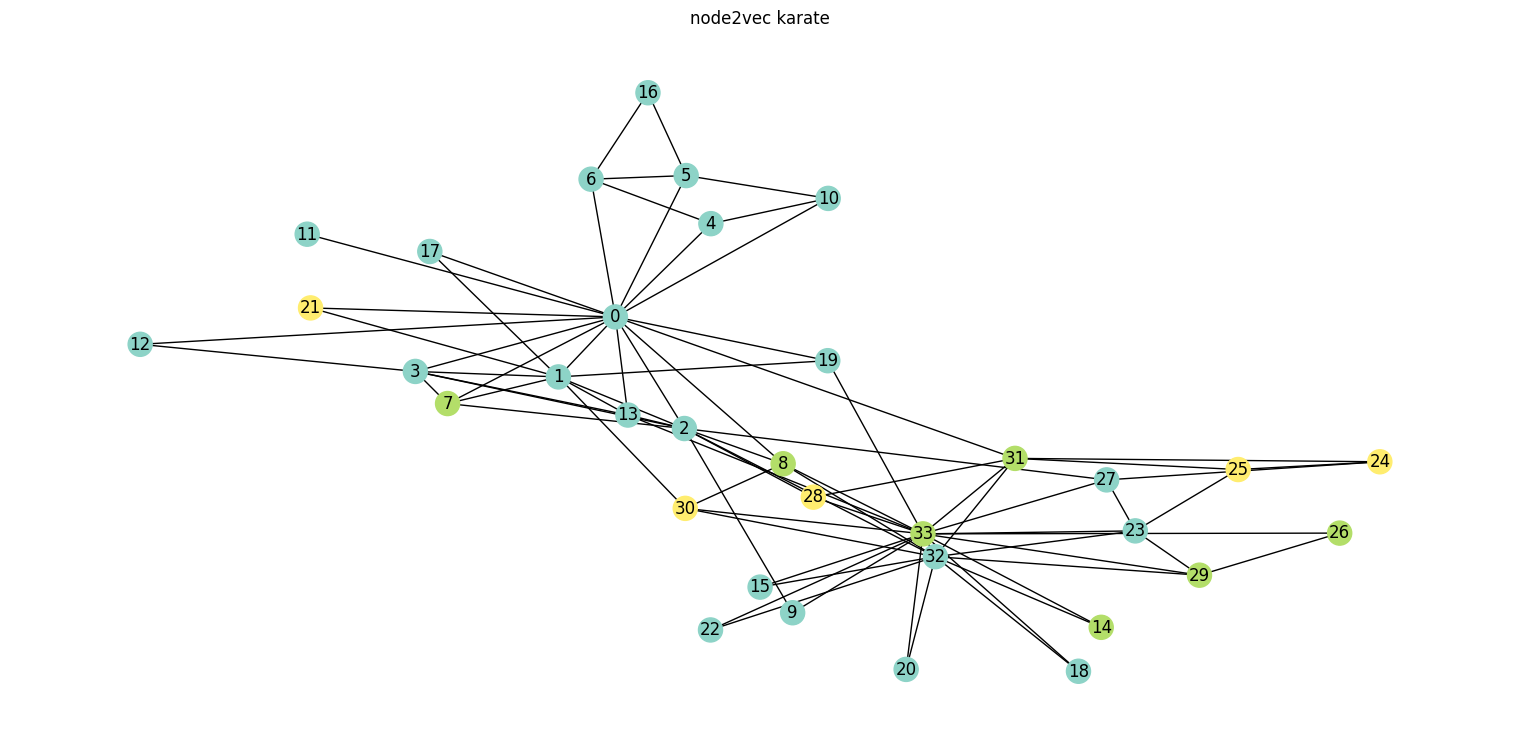

{'Number of Communities': 3,
 'Average Community Size': 11.333333333333334,
 'Modularity': 0.048715353910159076,
 'Coverage': 0.5512820512820513,
 'Performance': 0.5472370766488414}

In [14]:
best_eps = 0
best_mod = -1

for i in np.arange(0.1, 1.0, 0.01):
    dbscan = DBSCAN(eps=i, min_samples=5)
    communities = dbscan.fit_predict(node2vec_model.wv.get_normed_vectors())
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_eps, best_mod = i, mod


dbscan = DBSCAN(eps=best_eps, min_samples=5)
communities = dbscan.fit_predict(node2vec_model.wv.get_normed_vectors())
plot_communities(g, communities, title=f"node2vec {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

# Apply GAT Embedding

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [16]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [17]:
best_parameters = tune(data)
best_parameters

[I 2024-08-12 01:27:01,776] A new study created in memory with name: no-name-79bc5c3d-364b-4f4b-a850-7b41f1f32fac
[I 2024-08-12 01:27:02,863] Trial 0 finished with value: 0.07059500328731098 and parameters: {'hidden_channels': 51, 'out_channels': 14, 'heads': 9, 'learning_rate': 0.0003770687191188222, 'dropout': 0.1342268878407957, 'weight_decay': 0.00044851495098839676}. Best is trial 0 with value: 0.07059500328731098.
[I 2024-08-12 01:27:03,758] Trial 1 finished with value: 0.3745069033530572 and parameters: {'hidden_channels': 62, 'out_channels': 19, 'heads': 3, 'learning_rate': 0.0009946948153312675, 'dropout': 0.7551521524722344, 'weight_decay': 0.00013440806621513172}. Best is trial 1 with value: 0.3745069033530572.
[I 2024-08-12 01:27:04,592] Trial 2 finished with value: 0.37146614069691 and parameters: {'hidden_channels': 60, 'out_channels': 15, 'heads': 2, 'learning_rate': 0.00045004093956362744, 'dropout': 0.22854703717206923, 'weight_decay': 0.000540937676011207}. Best is tr

In [18]:
best_parameters.best_value

0.41880341880341876

In [19]:
hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
num_layers = best_parameters['num_layers']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 400

In [20]:
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

# Training the model
for epoch in range(800):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')


Epoch 0, Loss: 1.3775548934936523
Epoch 10, Loss: 0.2763814926147461
Epoch 20, Loss: 0.0058602700009942055
Epoch 30, Loss: 0.004754671826958656
Epoch 40, Loss: 0.02155047282576561
Epoch 50, Loss: 0.019446201622486115
Epoch 60, Loss: 2.630586862564087
Epoch 70, Loss: 0.25868380069732666
Epoch 80, Loss: 0.010551338084042072
Epoch 90, Loss: 0.010877532884478569
Epoch 100, Loss: 0.02013401873409748
Epoch 110, Loss: 3.5262750316178426e-05
Epoch 120, Loss: 0.8946728110313416
Epoch 130, Loss: 0.018016980960965157
Epoch 140, Loss: 0.0263957642018795
Epoch 150, Loss: 11.214427947998047
Epoch 160, Loss: 0.09904022514820099
Epoch 170, Loss: 0.12397035956382751
Epoch 180, Loss: 0.14060425758361816
Epoch 190, Loss: 0.1144995242357254
Epoch 200, Loss: 0.18072794377803802
Epoch 210, Loss: 0.15963642299175262
Epoch 220, Loss: 0.16379868984222412
Epoch 230, Loss: 0.08999966084957123
Epoch 240, Loss: 0.10173855721950531
Epoch 250, Loss: 1.1751242876052856
Epoch 260, Loss: 0.07792067527770996
Epoch 270, 

In [21]:
# Extract node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model.encoder(data.x, data.edge_index)

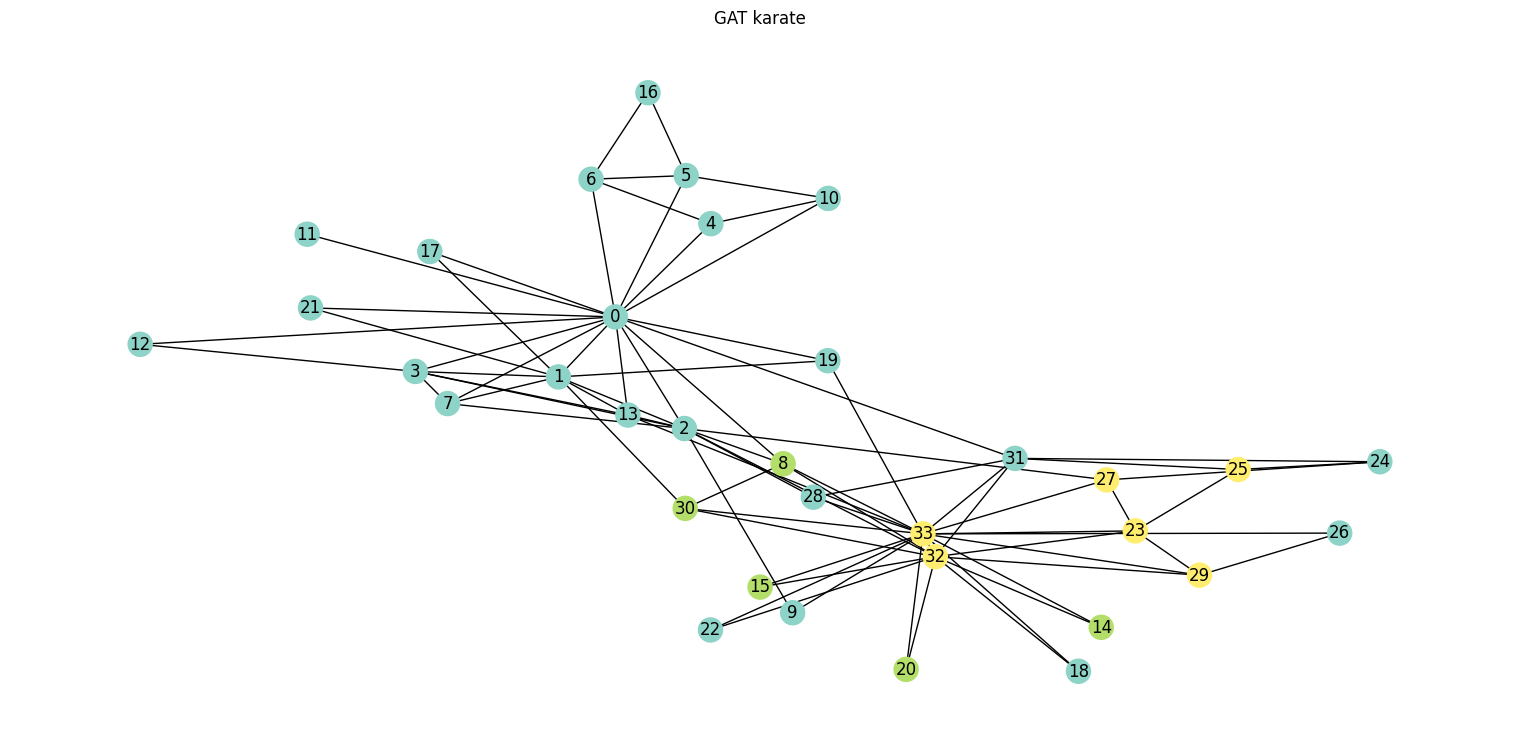

{'Number of Communities': 3,
 'Average Community Size': 11.333333333333334,
 'Modularity': 0.18197747418526639,
 'Coverage': 0.6153846153846154,
 'Performance': 0.5365418894830659}

In [22]:
best_eps = 0
best_mod = -1

for i in np.arange(0.1, 1.0, 0.01):
    dbscan = DBSCAN(eps=i, min_samples=5)
    communities = dbscan.fit_predict(node_embeddings.detach().cpu().numpy())
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_eps, best_mod = i, mod


dbscan = DBSCAN(eps=best_eps, min_samples=5)
communities = dbscan.fit_predict(node_embeddings.detach().cpu().numpy())
plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

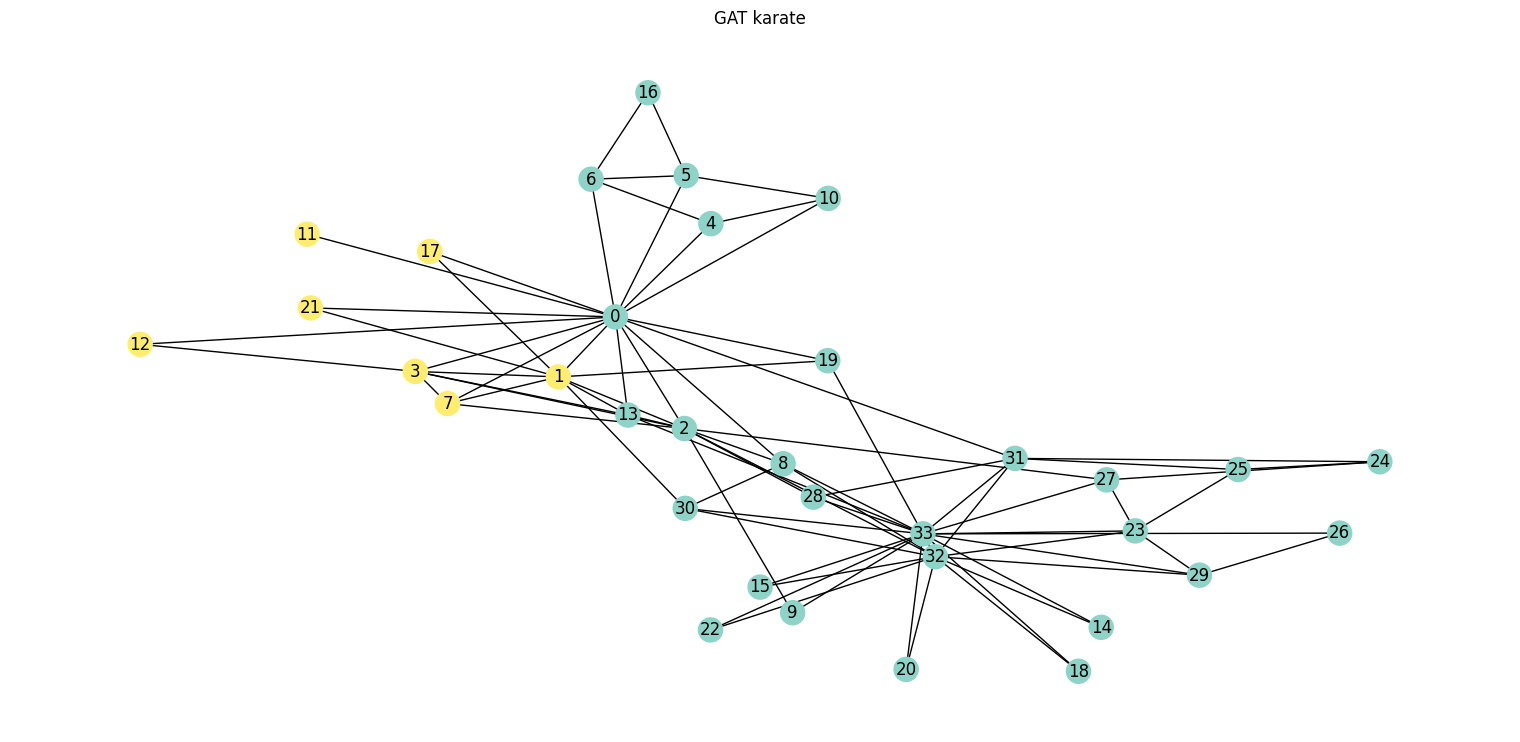

{'Number of Communities': 2,
 'Average Community Size': 17.0,
 'Modularity': 0.08721725604842484,
 'Coverage': 0.8205128205128205,
 'Performance': 0.42602495543672014}

In [23]:
# best_n = 0
# best_mod = -1

# for i in range(2, 11):
#     kmeans = KMeans(n_clusters=i)
#     communities = kmeans.fit_predict(node_embeddings.detach().cpu().numpy())
#     mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
#     if mod > best_mod:
#         best_n, best_mod = i, mod

kmeans = KMeans(n_clusters=2)
communities = kmeans.fit_predict(node_embeddings.detach().cpu().numpy())

plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

In [24]:
# Plotting the communities
# plt.figure(figsize=(8, 6))
# nx.draw(G, node_color=communities, with_labels=True, cmap=plt.cm.rainbow, node_size=500)
# plt.title("Detected Communities in Karate Club Graph")
# plt.show()